# 4.1. Desarrollar un planificador complejo que integre STRIPS, heurísticas y redes bayesianas

Partiendo de las nociones teóricas y prácticas vistas en la unidad, el alumno va a diseñar y desarrollar un planificador complejo. Tanto el diseño como el código deben ser entregados describiendo detalladamente cada uno de los procesos involucrados, así como la justificación y pertinencia de su implementación.

## 1. Diseño del sistema

En la práctica anterior (3.1) se implementó un planificador **STRIPS** clásico para un robot doméstico: los estados se representaban como conjuntos de hechos, las acciones como operadores con precondiciones/add-list/del-list, y la búsqueda del plan se resolvía con **BFS** (búsqueda en anchura) sobre el espacio de estados. Las conclusiones de esa práctica señalaban dos limitaciones concretas:

1. **BFS no escala.** Al ser una búsqueda no informada, expande estados en todas direcciones por igual; en dominios más grandes el número de estados visitados crece muy rápido. Se necesita una **heurística** que guíe la búsqueda hacia la meta.
2. **El mundo se modelaba como determinista.** Una puerta estaba "abierta" o "cerrada", sin término medio. En un entorno real hay **incertidumbre**: no siempre se sabe con certeza si un pasillo estará congestionado, si una zona tendrá tráfico, etc. Se necesita una forma de **razonar bajo incertidumbre**.

Esta práctica construye un planificador que resuelve ambas limitaciones, integrando tres piezas:

| Pieza | Rol en el planificador |
|---|---|
| **STRIPS** | Modela el dominio de forma declarativa: qué hechos son verdaderos, qué acciones existen, qué precondiciones necesitan y qué efectos producen. Es el "motor de reglas" del mundo. |
| **Heurísticas + búsqueda informada (A\*)** | Reemplaza el BFS ciego por **A\***, que usa una función `f(n) = g(n) + h(n)` para priorizar los estados más prometedores y encontrar planes de **costo mínimo** sin explorar todo el espacio de estados. |
| **Redes bayesianas** | Modelan variables inciertas del entorno (por ejemplo, si un pasillo está congestionado) a partir de evidencia observable (hora del día, eventos de inventario). La probabilidad inferida se traduce en un **costo esperado** que alimenta a `g(n)` en A\*. |

La integración ocurre en un único punto de contacto: **el costo de una acción `Mover` deja de ser fijo (1) y pasa a depender de la probabilidad de congestión de la zona a la que se mueve**, probabilidad que se obtiene consultando la red bayesiana bajo una evidencia dada. STRIPS sigue siendo responsable de qué acciones son *válidas*; la red bayesiana decide qué tan *costosas* son; A\* encuentra el plan de menor costo esperado dado ese modelo.

### Una quinta pieza: CBR + Sistema Basado en Reglas

El otro tema central de esta unidad fue la **integración de razonamiento basado en casos (CBR) con sistemas basados en reglas**. Ese tema encaja de forma natural aquí: en vez de resolver cada problema de entrega **siempre desde cero** con A\*, el planificador puede primero preguntarse "¿ya resolví algo parecido antes?". Esta idea añade una quinta pieza al sistema:

| Pieza | Rol en el planificador |
|---|---|
| **CBR (razonamiento basado en casos) + Reglas** | Mantiene una **base de casos** de problemas ya resueltos. Ante un problema nuevo, **recupera** el caso más similar, y un **motor de reglas** decide si conviene **adaptar** ese plan (reutilizarlo, total o parcialmente) o descartarlo y planificar desde cero con A\*. Un módulo de **evaluación y aprendizaje** valida la calidad de la solución adaptada y decide si se **retiene** como un nuevo caso, haciendo que el sistema mejore con la experiencia. |

Esta pieza se desarrolla en la sección 16, después de validar el planificador STRIPS+A\*+BN de forma independiente (secciones 3 a 15) — CBR **reutiliza** ese planificador tal cual (como mecanismo de "reutilización derivacional" cuando no hay un caso adaptable), no lo reemplaza.

## 2. Dominio: robot de almacén logístico

El dominio es distinto al robot doméstico de la práctica 3.1. Aquí un **robot de bodega** se mueve sobre una cuadrícula que representa el piso de un almacén, recoge paquetes ubicados junto a las estanterías y los entrega en el **muelle de carga**.

### 2.1 Geometría del piso

- Cuadrícula de `ANCHO=6` columnas (`x: 0..5`) por `ALTO=5` filas (`y: 0..4`).
- Dos bloques verticales de estanterías (**obstáculos**, celdas no transitables): `{(1,1),(1,2),(1,3)}` y `{(3,1),(3,2),(3,3)}`.
- Las filas `y=0` y `y=4` quedan completamente libres, formando **pasillos transversales** (sur y norte). Las columnas `x=0, 2, 4, 5` quedan libres en toda su altura, formando **pasillos verticales**, incluyendo el pasillo central `x=2` entre los dos bloques de estantería.

Representación gráfica de la cuadrícula (`XX` = estantería/obstáculo, `..` = celda libre; fila `y=4` arriba porque es el pasillo norte, `y=0` abajo porque es el pasillo sur):

```
     x0  x1  x2  x3  x4  x5
y=4  ..  ..  ..  ..  ..  ..
y=3  ..  XX  ..  XX  ..  ..
y=2  ..  XX  ..  XX  ..  ..
y=1  ..  XX  ..  XX  ..  ..
y=0  ..  ..  ..  ..  ..  ..
```

Se ven claramente los dos bloques de estantería (columnas `x=1` y `x=3`, filas `y=1..3`) y los tres pasillos verticales libres entre y alrededor de ellos (`x=0`, `x=2`, `x=4`, `x=5`).

### 2.2 Zonas

Para asociar congestión probabilística se agrupan las filas en tres zonas:

- **Sur** (`y=0`): pasillo transversal inferior, cercano al punto de partida del robot.
- **Centro** (`y=1,2,3`): pasillos entre los bloques de estantería, la zona más transitada por ser donde se recogen los paquetes.
- **Norte** (`y=4`): pasillo transversal superior, cercano al muelle de carga.

### 2.3 Entidades

| Entidad | Ubicación inicial |
|---|---|
| Robot | `(0,0)`, manos libres |
| Paquete A | `(2,1)` — pasillo central, junto al primer bloque de estantería |
| Paquete B | `(4,2)` — junto al segundo bloque de estantería |
| Muelle de carga (dock) | `(5,4)` — esquina opuesta al robot, obliga a atravesar las tres zonas |

El robot tiene capacidad para **un paquete a la vez** (igual que en 3.1, donde debía tener las manos libres para tomar un objeto). La tarea principal es entregar ambos paquetes en el muelle de carga.

In [1]:
import heapq
import itertools
from collections import deque
from dataclasses import dataclass
from typing import Callable, Optional

import sys
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

try:
    import pgmpy  # noqa: F401
except ImportError:
    !{sys.executable} -m pip install -q pgmpy
    import pgmpy  # noqa: F401

print(f"Python          {sys.version}")
print(f"matplotlib      {matplotlib.__version__}")
print(f"pgmpy version:  {pgmpy.__version__}")

Python          3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
matplotlib      3.10.7
pgmpy version:  1.1.2


## 3. Representación del estado y las acciones (STRIPS)

Se conserva el patrón de la práctica 3.1: un **hecho** es una tupla (por ejemplo `("en","robot",(0,0))`) y un **estado** es un `frozenset` de hechos — inmutable, por lo que puede usarse como clave en diccionarios/sets de visitados y como valor hasheable dentro de una `dataclass(frozen=True)`.

La clase `Accion` se extiende respecto a la de 3.1 con dos campos nuevos, necesarios para la integración con costos probabilísticos:

- `costo_base`: costo nominal de la acción cuando no hay incertidumbre (1.0 para moverse, 0.0 para tomar/dejar, ya que manipular un paquete se considera instantáneo).
- `zona`: la zona del piso a la que se dirige la acción (solo aplica a `Mover`); es la clave que luego se usará para consultar la probabilidad de congestión en la red bayesiana.

In [2]:
@dataclass(frozen=True)
class Accion:
    nombre: str
    precondiciones: frozenset
    add_list: frozenset
    del_list: frozenset
    costo_base: float = 1.0
    zona: Optional[str] = None

    def aplicable(self, estado: frozenset) -> bool:
        return self.precondiciones <= estado

    def aplicar(self, estado: frozenset) -> frozenset:
        return (estado - self.del_list) | self.add_list

    def __repr__(self):
        return self.nombre

## 4. El grid de la bodega

`zona_de_celda` clasifica cualquier celda en "Sur", "Centro" o "Norte" según su fila. `generar_celdas_libres` calcula todas las celdas transitables (todas menos las de estantería).

In [3]:
ANCHO, ALTO = 6, 5
OBSTACULOS = {(1, 1), (1, 2), (1, 3), (3, 1), (3, 2), (3, 3)}


def zona_de_celda(celda):
    _, y = celda
    if y == 0:
        return "Sur"
    if y == ALTO - 1:
        return "Norte"
    return "Centro"


def generar_celdas_libres(ancho, alto, obstaculos):
    return [(x, y) for x in range(ancho) for y in range(alto) if (x, y) not in obstaculos]


CELDAS_LIBRES = generar_celdas_libres(ANCHO, ALTO, OBSTACULOS)
print(f"Celdas libres: {len(CELDAS_LIBRES)} de {ANCHO * ALTO} totales")
print(f"Celdas de estantería (obstáculo): {len(OBSTACULOS)}")

Celdas libres: 24 de 30 totales
Celdas de estantería (obstáculo): 6


## 5. Operadores del dominio (esquemas STRIPS)

| Operador | Precondiciones | Add-list | Del-list |
|---|---|---|---|
| `Mover(desde, hasta)` | robot en `desde`; `hasta` es celda adyacente y libre | robot en `hasta` | robot en `desde` |
| `Tomar(paquete, ubicacion)` | robot en `ubicacion`; paquete en `ubicacion`; manos libres | robot sosteniendo paquete | paquete en `ubicacion`; manos libres |
| `Dejar(paquete, ubicacion)` | robot en `ubicacion`; robot sosteniendo paquete | paquete en `ubicacion`; manos libres | robot sosteniendo paquete |

`Mover` no necesita comprobar precondiciones de "puerta abierta" como en 3.1 — aquí la restricción física es simplemente que la celda destino no sea una estantería, lo cual ya se garantiza al generar el operador solo entre celdas libres adyacentes.

In [4]:
def accion_mover(desde, hasta):
    return Accion(
        nombre=f"Mover({desde}->{hasta})",
        precondiciones=frozenset({("en", "robot", desde)}),
        add_list=frozenset({("en", "robot", hasta)}),
        del_list=frozenset({("en", "robot", desde)}),
        costo_base=1.0,
        zona=zona_de_celda(hasta),
    )


def accion_tomar(paquete, ubicacion):
    return Accion(
        nombre=f"Tomar({paquete}@{ubicacion})",
        precondiciones=frozenset({
            ("en", "robot", ubicacion),
            ("en", paquete, ubicacion),
            ("manos_libres", "robot"),
        }),
        add_list=frozenset({("sosteniendo", "robot", paquete)}),
        del_list=frozenset({("en", paquete, ubicacion), ("manos_libres", "robot")}),
        costo_base=0.0,
    )


def accion_dejar(paquete, ubicacion):
    return Accion(
        nombre=f"Dejar({paquete}@{ubicacion})",
        precondiciones=frozenset({
            ("en", "robot", ubicacion),
            ("sosteniendo", "robot", paquete),
        }),
        add_list=frozenset({("en", paquete, ubicacion), ("manos_libres", "robot")}),
        del_list=frozenset({("sosteniendo", "robot", paquete)}),
        costo_base=0.0,
    )


def celdas_adyacentes(celda, celdas_libres_set):
    x, y = celda
    vecinos = [(x + 1, y), (x - 1, y), (x, y + 1), (x, y - 1)]
    return [v for v in vecinos if v in celdas_libres_set]


def generar_operadores(celdas_libres, paquetes):
    celdas_set = set(celdas_libres)
    operadores = []
    for celda in celdas_libres:
        for vecino in celdas_adyacentes(celda, celdas_set):
            operadores.append(accion_mover(celda, vecino))
    for paquete in paquetes:
        for celda in celdas_libres:
            operadores.append(accion_tomar(paquete, celda))
            operadores.append(accion_dejar(paquete, celda))
    return operadores

In [5]:
ROBOT_INICIAL = (0, 0)
DOCK = (5, 4)
PAQUETES = {"paqueteA": (2, 1), "paqueteB": (4, 2)}

estado_inicial = frozenset(
    {("en", "robot", ROBOT_INICIAL), ("manos_libres", "robot")}
    | {("en", nombre, celda) for nombre, celda in PAQUETES.items()}
)

operadores = generar_operadores(CELDAS_LIBRES, list(PAQUETES.keys()))

print(f"Estado inicial: {len(estado_inicial)} hechos")
for hecho in sorted(estado_inicial, key=str):
    print("  ", hecho)
print(f"Operadores generados: {len(operadores)}")

Estado inicial: 4 hechos
   ('en', 'paqueteA', (2, 1))
   ('en', 'paqueteB', (4, 2))
   ('en', 'robot', (0, 0))
   ('manos_libres', 'robot')
Operadores generados: 154


### 4.1 Visualización del grid

La descripción de la geometría (sección 2.1) se traduce aquí en una cuadrícula gráfica: celdas grises son estanterías (obstáculo), el color de fondo indica la zona (Sur/Centro/Norte) y los marcadores señalan al robot, el muelle de carga y los paquetes en sus posiciones iniciales.

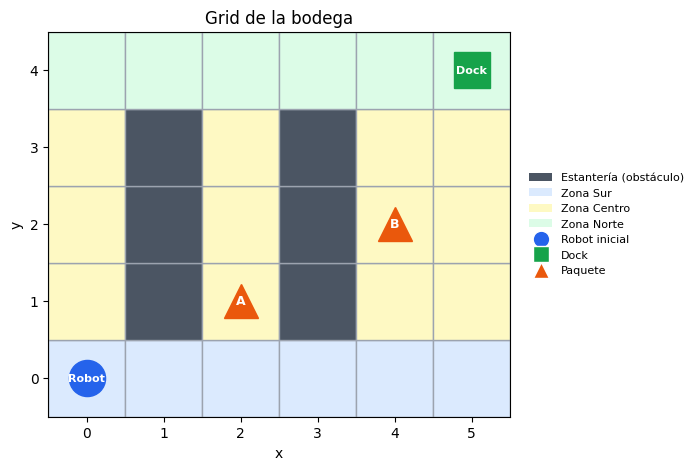

In [6]:
def graficar_grid(ax=None, titulo="Grid de la bodega"):
    if ax is None:
        _, ax = plt.subplots(figsize=(ANCHO, ALTO))

    color_zona = {"Sur": "#dbeafe", "Centro": "#fef9c3", "Norte": "#dcfce7"}
    for x in range(ANCHO):
        for y in range(ALTO):
            celda = (x, y)
            color = "#4b5563" if celda in OBSTACULOS else color_zona[zona_de_celda(celda)]
            ax.add_patch(mpatches.Rectangle((x - 0.5, y - 0.5), 1, 1, facecolor=color, edgecolor="#9ca3af"))

    ax.plot(*ROBOT_INICIAL, marker="o", markersize=26, color="#2563eb", zorder=3)
    ax.annotate("Robot", ROBOT_INICIAL, ha="center", va="center", color="white", fontsize=8, fontweight="bold", zorder=4)

    ax.plot(*DOCK, marker="s", markersize=26, color="#16a34a", zorder=3)
    ax.annotate("Dock", DOCK, ha="center", va="center", color="white", fontsize=8, fontweight="bold", zorder=4)

    for nombre, celda in PAQUETES.items():
        ax.plot(*celda, marker="^", markersize=24, color="#ea580c", zorder=3)
        ax.annotate(nombre.replace("paquete", ""), celda, ha="center", va="center", color="white", fontsize=9, fontweight="bold", zorder=4)

    ax.set_xlim(-0.5, ANCHO - 0.5)
    ax.set_ylim(-0.5, ALTO - 0.5)
    ax.set_xticks(range(ANCHO))
    ax.set_yticks(range(ALTO))
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(titulo)
    ax.set_aspect("equal")

    leyenda = [
        mpatches.Patch(facecolor="#4b5563", label="Estantería (obstáculo)"),
        mpatches.Patch(facecolor="#dbeafe", label="Zona Sur"),
        mpatches.Patch(facecolor="#fef9c3", label="Zona Centro"),
        mpatches.Patch(facecolor="#dcfce7", label="Zona Norte"),
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#2563eb", markersize=12, label="Robot inicial"),
        plt.Line2D([0], [0], marker="s", color="w", markerfacecolor="#16a34a", markersize=12, label="Dock"),
        plt.Line2D([0], [0], marker="^", color="w", markerfacecolor="#ea580c", markersize=12, label="Paquete"),
    ]
    ax.legend(handles=leyenda, loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8, frameon=False)
    return ax


graficar_grid()
plt.show()

## 6. Heurística: distancia Manhattan

Para guiar la búsqueda hacia la meta se usa la **distancia Manhattan** entre dos celdas, `|x1-x2| + |y1-y2|`, que es exactamente el número mínimo de movimientos de un solo paso (4-conexo) necesarios para ir de una celda a otra **si no hubiera obstáculos**. Quitar obstáculos nunca puede alargar el camino más corto, así que la distancia Manhattan es siempre una cota inferior del número real de pasos, incluso en presencia de estanterías.

### Admisibilidad para una sola meta pendiente

Sea `h(estado) = manhattan(robot, paquete) + manhattan(paquete, destino)` (o `manhattan(robot, destino)` si el robot ya sostiene el paquete). Como el costo de cada movimiento es `costo_base * (1 + p_congestion) ≥ 1` (la probabilidad nunca es negativa), el costo real de cualquier plan es al menos igual al número de movimientos que contiene. Y el número mínimo de movimientos para completar una sola entrega es exactamente la suma de distancias Manhattan de arriba. Por lo tanto:

`h(estado) ≤ número_mínimo_de_movimientos ≤ costo_real_del_plan_óptimo`

`h` nunca sobreestima → es **admisible** → A\* con esta heurística garantiza encontrar el plan de costo mínimo cuando la meta involucra un solo paquete pendiente.

In [7]:
def distancia_manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def extraer_posicion(estado, entidad):
    for hecho in estado:
        if hecho[0] == "en" and hecho[1] == entidad:
            return hecho[2]
    return None


def heuristica_suma_manhattan(estado, meta):
    robot_pos = extraer_posicion(estado, "robot")
    total = 0
    for hecho in meta:
        if hecho in estado:
            continue
        tipo, paquete, destino = hecho
        if tipo != "en":
            continue
        if ("sosteniendo", "robot", paquete) in estado:
            total += distancia_manhattan(robot_pos, destino)
        else:
            paquete_pos = extraer_posicion(estado, paquete)
            total += distancia_manhattan(robot_pos, paquete_pos) + distancia_manhattan(paquete_pos, destino)
    return total


# Para una sola meta pendiente la fórmula es admisible (demostrado arriba).
heuristica_un_paquete = heuristica_suma_manhattan

## 7. Búsqueda: BFS (referencia) y A\* (búsqueda informada)

`planificar_bfs` es la misma búsqueda en anchura de la práctica 3.1, adaptada para poder calcular el costo real de un plan a posteriori (usando `funcion_costo` si se provee, o contando 1 por paso si no).

`planificar_a_estrella` implementa A\* con una cola de prioridad (`heapq`): cada entrada es `(f, g, contador, estado, plan)`. El `contador` (un `itertools.count()`) es necesario como criterio de desempate — si dos entradas tienen el mismo `f`, Python intentaría comparar `estado` (un `frozenset`) o `plan` (una lista de `Accion`), que no son comparables entre sí y provocarían un `TypeError` intermitente.

Se usa `mejor_costo` (un diccionario `estado -> mejor g conocido`) en vez de un simple set de visitados: como los costos ya no son uniformes, un estado puede reencontrarse más adelante con un costo menor al ya registrado, y en ese caso debe **reabrirse**.

In [8]:
@dataclass
class ResultadoBusqueda:
    plan: list
    costo_total: float
    nodos_expandidos: int
    nodos_generados: int


def _costo_plan(plan, funcion_costo):
    if funcion_costo is None:
        return sum(accion.costo_base for accion in plan)
    return sum(funcion_costo(accion) for accion in plan)


def planificar_bfs(estado_inicial, meta, operadores, funcion_costo=None):
    frontera = deque([(estado_inicial, [])])
    visitados = {estado_inicial}
    nodos_expandidos = 0
    nodos_generados = 1

    while frontera:
        estado, plan = frontera.popleft()
        if meta <= estado:
            return ResultadoBusqueda(plan, _costo_plan(plan, funcion_costo), nodos_expandidos, nodos_generados)
        nodos_expandidos += 1
        for accion in operadores:
            if accion.aplicable(estado):
                nuevo_estado = accion.aplicar(estado)
                if nuevo_estado not in visitados:
                    visitados.add(nuevo_estado)
                    nodos_generados += 1
                    frontera.append((nuevo_estado, plan + [accion]))
    return None


def planificar_a_estrella(estado_inicial, meta, operadores, funcion_costo, heuristica):
    contador = itertools.count()
    frontera = [(heuristica(estado_inicial, meta), 0.0, next(contador), estado_inicial, [])]
    mejor_costo = {estado_inicial: 0.0}
    nodos_expandidos = 0
    nodos_generados = 1

    while frontera:
        f, g, _, estado, plan = heapq.heappop(frontera)
        if g > mejor_costo.get(estado, float("inf")):
            continue  # entrada obsoleta: ya existe un camino mejor a este estado
        if meta <= estado:
            return ResultadoBusqueda(plan, g, nodos_expandidos, nodos_generados)
        nodos_expandidos += 1
        for accion in operadores:
            if accion.aplicable(estado):
                nuevo_estado = accion.aplicar(estado)
                costo_accion = funcion_costo(accion) if funcion_costo else accion.costo_base
                nuevo_g = g + costo_accion
                if nuevo_g < mejor_costo.get(nuevo_estado, float("inf")):
                    mejor_costo[nuevo_estado] = nuevo_g
                    nuevo_h = heuristica(nuevo_estado, meta)
                    nodos_generados += 1
                    heapq.heappush(
                        frontera,
                        (nuevo_g + nuevo_h, nuevo_g, next(contador), nuevo_estado, plan + [accion]),
                    )
    return None

### Demostración: caso simple (1 paquete, sin congestión)

Antes de introducir incertidumbre se compara BFS contra A\* en el caso más simple: entregar solo el paquete A, con `funcion_costo=None` (equivalente a costo uniforme 1 por movimiento). En este caso **ambos algoritmos deben encontrar un plan del mismo costo** — la diferencia entre ellos es cuántos nodos necesitan explorar para llegar ahí, no la calidad del plan.

In [9]:
meta_paquete_a = frozenset({("en", "paqueteA", DOCK)})

resultado_bfs = planificar_bfs(estado_inicial, meta_paquete_a, operadores)
resultado_astar = planificar_a_estrella(
    estado_inicial, meta_paquete_a, operadores, funcion_costo=None, heuristica=heuristica_un_paquete
)

print("BFS -> costo:", resultado_bfs.costo_total,
      " nodos_expandidos:", resultado_bfs.nodos_expandidos,
      " nodos_generados:", resultado_bfs.nodos_generados)
print("A*  -> costo:", resultado_astar.costo_total,
      " nodos_expandidos:", resultado_astar.nodos_expandidos,
      " nodos_generados:", resultado_astar.nodos_generados)

assert resultado_bfs.costo_total == resultado_astar.costo_total, "BFS y A* deberían coincidir en el costo cuando el costo es uniforme"
print("\nPlan (A*):", [a.nombre for a in resultado_astar.plan])

BFS -> costo: 9.0  nodos_expandidos: 203  nodos_generados: 311
A*  -> costo: 9.0  nodos_expandidos: 17  nodos_generados: 37

Plan (A*): ['Mover((0, 0)->(1, 0))', 'Mover((1, 0)->(2, 0))', 'Mover((2, 0)->(2, 1))', 'Tomar(paqueteA@(2, 1))', 'Mover((2, 1)->(2, 2))', 'Mover((2, 2)->(2, 3))', 'Mover((2, 3)->(2, 4))', 'Mover((2, 4)->(3, 4))', 'Mover((3, 4)->(4, 4))', 'Mover((4, 4)->(5, 4))', 'Dejar(paqueteA@(5, 4))']


## 8. Traza de A\* paso a paso

Igual que en la práctica 3.1 se incluyó una versión "trazada" de BFS, aquí se incluye una versión trazada de A\* que imprime, en cada iteración, qué estado se extrae de la cola de prioridad (con su `f` y `g`), qué acciones se consideran, y si cada sucesor se agrega a la frontera o se descarta por no mejorar el costo conocido. Se ejecuta sobre un grid reducido de 3×3 sin obstáculos para que la traza sea legible.

In [10]:
def planificar_a_estrella_trazado(estado_inicial, meta, operadores, funcion_costo, heuristica, max_iter=50):
    contador = itertools.count()
    frontera = [(heuristica(estado_inicial, meta), 0.0, next(contador), estado_inicial, [])]
    mejor_costo = {estado_inicial: 0.0}
    iteracion = 0

    while frontera and iteracion < max_iter:
        iteracion += 1
        f, g, _, estado, plan = heapq.heappop(frontera)
        print(f"--- Iteración {iteracion}: extraído f={f:.2f} g={g:.2f} robot_en={extraer_posicion(estado, 'robot')} ---")
        if g > mejor_costo.get(estado, float("inf")):
            print("    (entrada obsoleta, se descarta)")
            continue
        if meta <= estado:
            print("    ¡Meta alcanzada!")
            return ResultadoBusqueda(plan, g, iteracion, len(mejor_costo))
        for accion in operadores:
            if accion.aplicable(estado):
                nuevo_estado = accion.aplicar(estado)
                costo_accion = funcion_costo(accion) if funcion_costo else accion.costo_base
                nuevo_g = g + costo_accion
                if nuevo_g < mejor_costo.get(nuevo_estado, float("inf")):
                    mejor_costo[nuevo_estado] = nuevo_g
                    nuevo_h = heuristica(nuevo_estado, meta)
                    print(f"    -> agrega {accion.nombre}: g={nuevo_g:.2f} h={nuevo_h:.2f} f={nuevo_g + nuevo_h:.2f}")
                    heapq.heappush(
                        frontera,
                        (nuevo_g + nuevo_h, nuevo_g, next(contador), nuevo_estado, plan + [accion]),
                    )
                else:
                    print(f"    -> descarta {accion.nombre} (ya existe un camino igual o mejor)")
    return None


celdas_reducidas = generar_celdas_libres(3, 3, set())
paquete_reducido = {"paqueteX": (2, 0)}
estado_reducido = frozenset(
    {("en", "robot", (0, 0)), ("manos_libres", "robot")}
    | {("en", nombre, celda) for nombre, celda in paquete_reducido.items()}
)
operadores_reducidos = generar_operadores(celdas_reducidas, list(paquete_reducido.keys()))
meta_reducida = frozenset({("en", "paqueteX", (0, 2))})

resultado_trazado = planificar_a_estrella_trazado(
    estado_reducido, meta_reducida, operadores_reducidos, funcion_costo=None, heuristica=heuristica_un_paquete
)
print("\nPlan encontrado:", [a.nombre for a in resultado_trazado.plan])

--- Iteración 1: extraído f=6.00 g=0.00 robot_en=(0, 0) ---
    -> agrega Mover((0, 0)->(1, 0)): g=1.00 h=5.00 f=6.00
    -> agrega Mover((0, 0)->(0, 1)): g=1.00 h=7.00 f=8.00
--- Iteración 2: extraído f=6.00 g=1.00 robot_en=(1, 0) ---
    -> agrega Mover((1, 0)->(2, 0)): g=2.00 h=4.00 f=6.00
    -> descarta Mover((1, 0)->(0, 0)) (ya existe un camino igual o mejor)
    -> agrega Mover((1, 0)->(1, 1)): g=2.00 h=6.00 f=8.00
--- Iteración 3: extraído f=6.00 g=2.00 robot_en=(2, 0) ---
    -> descarta Mover((2, 0)->(1, 0)) (ya existe un camino igual o mejor)
    -> agrega Mover((2, 0)->(2, 1)): g=3.00 h=5.00 f=8.00
    -> agrega Tomar(paqueteX@(2, 0)): g=2.00 h=4.00 f=6.00
--- Iteración 4: extraído f=6.00 g=2.00 robot_en=(2, 0) ---
    -> agrega Mover((2, 0)->(1, 0)): g=3.00 h=3.00 f=6.00
    -> agrega Mover((2, 0)->(2, 1)): g=3.00 h=3.00 f=6.00
    -> descarta Dejar(paqueteX@(2, 0)) (ya existe un camino igual o mejor)
--- Iteración 5: extraído f=6.00 g=3.00 robot_en=(1, 0) ---
    -> desca

## 9. Extensión a dos paquetes: ¿sigue siendo admisible la heurística?

Cuando la meta exige entregar **dos** paquetes simultáneamente, la fórmula natural es sumar la contribución de cada paquete pendiente: `heuristica_multi_paquete = heuristica_suma_manhattan` (la misma función de antes, aplicada ahora sobre una meta con dos hechos pendientes).

**Esto ya no está garantizado que sea admisible.** La razón: cada término de la suma se calcula *desde la posición actual del robot*, como si el robot pudiera "bifurcarse" y atender ambos paquetes en paralelo desde donde está parado ahora mismo. En la realidad el robot solo puede estar en un lugar a la vez: entrega el primer paquete y **desde el muelle** (no desde su posición original) va por el segundo. Si ambos paquetes están, por ejemplo, en la misma dirección general respecto al robot, la suma de las dos distancias "desde la posición actual" puede **sobreestimar** el costo real de la ruta secuencial óptima, violando la condición de admisibilidad (`h` nunca debe sobreestimar).

**Consecuencia práctica:** A\* con esta heurística sigue siendo **completo** (encuentra un plan si existe, porque el algoritmo de expansión no cambia), pero **pierde la garantía de optimalidad** para metas con más de un paquete pendiente. Se acepta esta pérdida de rigor a cambio de una heurística simple y rápida de calcular; es una decisión de diseño explícita, no un descuido, y se documenta aquí y en las conclusiones.

In [11]:
# Misma fórmula que heuristica_un_paquete; el nombre distinto documenta que aquí
# ya NO hay garantía de admisibilidad (ver discusión arriba).
heuristica_multi_paquete = heuristica_suma_manhattan

## 10. Redes bayesianas: ¿qué hace pgmpy por dentro?

Antes de usar `pgmpy` como caja de herramientas conviene entender el mecanismo de inferencia que implementa. Se construye aquí, en Python puro, una red bayesiana mínima de **2 nodos** — `HoraPico -> Congestion_Sur` — y el algoritmo estándar de inferencia exacta por **enumeración** (`enumeration-ask`, Russell & Norvig).

### Componentes

- **Nodos** y **padres**: la estructura del grafo (qué variable depende de cuáles).
- **CPTs** (tablas de probabilidad condicional): `P(nodo=True | valores de sus padres)`.
- **Probabilidad conjunta** de una asignación completa: producto de `P(nodo=valor | padres)` sobre todos los nodos (regla de la cadena para redes bayesianas).
- **`enumeration_ask(variable, evidencia)`**: para responder `P(variable | evidencia)`, se suma la probabilidad conjunta sobre todas las combinaciones posibles de las variables *no observadas y no consultadas*, una vez para `variable=True` y otra para `variable=False`, y se normaliza para que ambas sumen 1.

Los valores concretos de este ejemplo (`P(Congestion_Sur=True | HoraPico=False)=0.12`, `P(Congestion_Sur=True | HoraPico=True)=0.62`) son el resultado de marginalizar la variable `EventoInventario` (con su probabilidad previa) sobre la tabla completa de congestión que se usará más adelante en la red del dominio — así el resultado de este ejemplo simplificado se podrá comparar numéricamente contra la red completa de pgmpy.

In [12]:
class RedBayesianaSimple:
    def __init__(self, nodos, padres, cpts):
        self.nodos = nodos
        self.padres = padres
        self.cpts = cpts  # cpts[nodo][tupla_valores_de_los_padres] = P(nodo=True | padres)

    def probabilidad_nodo(self, nodo, valor, asignacion):
        padres_nodo = self.padres[nodo]
        clave = tuple(asignacion[p] for p in padres_nodo)
        p_true = self.cpts[nodo][clave]
        return p_true if valor else (1 - p_true)

    def probabilidad_conjunta(self, asignacion):
        p = 1.0
        for nodo in self.nodos:
            p *= self.probabilidad_nodo(nodo, asignacion[nodo], asignacion)
        return p

    def enumeration_ask(self, variable_consulta, evidencia):
        otras = [n for n in self.nodos if n not in evidencia and n != variable_consulta]
        resultado = {}
        for valor_consulta in (False, True):
            total = 0.0
            asignacion_base = dict(evidencia)
            asignacion_base[variable_consulta] = valor_consulta
            for combinacion in itertools.product([False, True], repeat=len(otras)):
                asignacion = dict(asignacion_base)
                asignacion.update(zip(otras, combinacion))
                total += self.probabilidad_conjunta(asignacion)
            resultado[valor_consulta] = total
        normalizador = sum(resultado.values())
        return {k: v / normalizador for k, v in resultado.items()}


red_simple = RedBayesianaSimple(
    nodos=["HoraPico", "Congestion_Sur"],
    padres={"HoraPico": [], "Congestion_Sur": ["HoraPico"]},
    cpts={
        "HoraPico": {(): 0.3},
        "Congestion_Sur": {(False,): 0.12, (True,): 0.62},
    },
)

print(f"{'HoraPico':<10}{'Congestion_Sur':<16}{'P(conjunta)':<12}")
suma = 0.0
for hp in (False, True):
    for cs in (False, True):
        p = red_simple.probabilidad_conjunta({"HoraPico": hp, "Congestion_Sur": cs})
        suma += p
        print(f"{str(hp):<10}{str(cs):<16}{p:.4f}")
print("Suma total (debe ser 1.0):", round(suma, 6))

marginal = red_simple.enumeration_ask("Congestion_Sur", {})
print("\nP(Congestion_Sur) sin evidencia:", {k: round(v, 4) for k, v in marginal.items()})

condicional = red_simple.enumeration_ask("Congestion_Sur", {"HoraPico": True})
print("P(Congestion_Sur | HoraPico=True):", {k: round(v, 4) for k, v in condicional.items()})
assert abs(condicional[True] - 0.62) < 1e-9, "Con evidencia completa, enumeration_ask debe reproducir la fila de la CPT"
print("(coincide exactamente con la fila de la CPT, como se esperaba)")

HoraPico  Congestion_Sur  P(conjunta) 
False     False           0.6160
False     True            0.0840
True      False           0.1140
True      True            0.1860
Suma total (debe ser 1.0): 1.0

P(Congestion_Sur) sin evidencia: {False: 0.73, True: 0.27}
P(Congestion_Sur | HoraPico=True): {False: 0.38, True: 0.62}
(coincide exactamente con la fila de la CPT, como se esperaba)


## 11. Red bayesiana del almacén (pgmpy)

La red real del dominio tiene 5 nodos binarios:

- `HoraPico` y `EventoInventario`: nodos raíz (evidencia observable, sin padres).
- `Congestion_Sur`, `Congestion_Centro`, `Congestion_Norte`: un nodo de congestión por zona, cada uno con `HoraPico` y `EventoInventario` como padres.

La intuición detrás de las probabilidades: la zona **Centro** (donde están las estanterías y se recogen los paquetes) es la más sensible a un evento de inventario en curso; la zona **Sur** (cercana a la entrada) se satura más en hora pico; la zona **Norte** (cercana al muelle, menos transitada) es la menos afectada en general.

`CPT_CONGESTION` es la única fuente de verdad para estos números: se usa tanto para construir las `TabularCPD` de pgmpy como, en la celda siguiente, para verificar el resultado contra el motor manual — así no hay que transcribir los valores dos veces (evitando errores de copiado).

In [13]:
CPT_CONGESTION = {
    # clave = (HoraPico, EventoInventario) -> P(Congestion_zona = True | HoraPico, EventoInventario)
    "Congestion_Sur":    {(False, False): 0.10, (False, True): 0.20, (True, False): 0.60, (True, True): 0.70},
    "Congestion_Centro": {(False, False): 0.15, (False, True): 0.65, (True, False): 0.40, (True, True): 0.85},
    "Congestion_Norte":  {(False, False): 0.05, (False, True): 0.10, (True, False): 0.20, (True, True): 0.30},
}
PRIOR_HORA_PICO = 0.3
PRIOR_EVENTO_INVENTARIO = 0.2

try:
    from pgmpy.models import DiscreteBayesianNetwork as ModeloBN
except ImportError:
    from pgmpy.models import BayesianNetwork as ModeloBN
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination


def construir_modelo_bodega(cpt_congestion, prior_hora_pico, prior_evento):
    zonas = list(cpt_congestion.keys())
    aristas = [("HoraPico", zona) for zona in zonas] + [("EventoInventario", zona) for zona in zonas]
    modelo = ModeloBN(aristas)

    cpd_hora_pico = TabularCPD(
        "HoraPico", 2, [[1 - prior_hora_pico], [prior_hora_pico]],
        state_names={"HoraPico": ["False", "True"]},
    )
    cpd_evento = TabularCPD(
        "EventoInventario", 2, [[1 - prior_evento], [prior_evento]],
        state_names={"EventoInventario": ["False", "True"]},
    )

    cpds = [cpd_hora_pico, cpd_evento]
    combinaciones = [(False, False), (False, True), (True, False), (True, True)]
    for zona, tabla in cpt_congestion.items():
        fila_true = [tabla[c] for c in combinaciones]
        fila_false = [1 - v for v in fila_true]
        cpds.append(TabularCPD(
            zona, 2, [fila_false, fila_true],
            evidence=["HoraPico", "EventoInventario"], evidence_card=[2, 2],
            state_names={
                zona: ["False", "True"],
                "HoraPico": ["False", "True"],
                "EventoInventario": ["False", "True"],
            },
        ))

    modelo.add_cpds(*cpds)
    assert modelo.check_model()
    return modelo, VariableElimination(modelo)


modelo_bodega, inferencia = construir_modelo_bodega(CPT_CONGESTION, PRIOR_HORA_PICO, PRIOR_EVENTO_INVENTARIO)
print(modelo_bodega.get_cpds("Congestion_Sur"))

C:\Users\sebas\AppData\Local\Programs\Python\Python313\Lib\site-packages\pgmpy\estimators\__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


+-----------------------+-----+------------------------+
| HoraPico              | ... | HoraPico(True)         |
+-----------------------+-----+------------------------+
| EventoInventario      | ... | EventoInventario(True) |
+-----------------------+-----+------------------------+
| Congestion_Sur(False) | ... | 0.30000000000000004    |
+-----------------------+-----+------------------------+
| Congestion_Sur(True)  | ... | 0.7                    |
+-----------------------+-----+------------------------+


In [14]:
def calcular_congestion(inferencia, hora_pico, evento_inventario):
    evidencia = {
        "HoraPico": "True" if hora_pico else "False",
        "EventoInventario": "True" if evento_inventario else "False",
    }
    resultado = {}
    for zona in ["Congestion_Sur", "Congestion_Centro", "Congestion_Norte"]:
        factor = inferencia.query([zona], evidence=evidencia, show_progress=False)
        resultado[zona] = factor.get_value(**{zona: "True"})
    return resultado


print("P(congestión | hora pico, evento de inventario):")
print(calcular_congestion(inferencia, hora_pico=True, evento_inventario=True))
print("\nP(congestión | valle, sin evento):")
print(calcular_congestion(inferencia, hora_pico=False, evento_inventario=False))

P(congestión | hora pico, evento de inventario):
{'Congestion_Sur': np.float64(0.7), 'Congestion_Centro': np.float64(0.85), 'Congestion_Norte': np.float64(0.3)}

P(congestión | valle, sin evento):
{'Congestion_Sur': np.float64(0.1), 'Congestion_Centro': np.float64(0.15), 'Congestion_Norte': np.float64(0.05)}


## 12. Validación cruzada: pgmpy contra el motor manual

`P(Congestion_Sur=True)` sin evidencia debe coincidir entre los dos motores, porque el ejemplo de 2 nodos de la sección 10 se derivó marginalizando `EventoInventario` (con su probabilidad previa) sobre exactamente esta misma tabla `CPT_CONGESTION`. No es una coincidencia trivial: involucra que ambos motores hagan la misma suma ponderada sobre las 4 combinaciones de `(HoraPico, EventoInventario)`.

In [15]:
factor_marginal = inferencia.query(["Congestion_Sur"], evidence={}, show_progress=False)
p_pgmpy = factor_marginal.get_value(Congestion_Sur="True")
p_manual = red_simple.enumeration_ask("Congestion_Sur", {})[True]

print(f"pgmpy  -> P(Congestion_Sur=True) = {p_pgmpy:.4f}")
print(f"manual -> P(Congestion_Sur=True) = {p_manual:.4f}")

assert abs(p_pgmpy - p_manual) < 1e-9, "Los dos motores de inferencia deberían coincidir"
print("Ambos motores de inferencia coinciden.")

pgmpy  -> P(Congestion_Sur=True) = 0.2700
manual -> P(Congestion_Sur=True) = 0.2700
Ambos motores de inferencia coinciden.


## 13. Integración: de la probabilidad al costo de planificación

Cada acción `Mover` tiene un `zona` (a dónde se dirige) y un `costo_base` (1.0). El costo real que ve A\* se calcula como:

`costo(Mover) = costo_base * (1 + P(Congestion_zona = True | evidencia))`

Esta fórmula mantiene la propiedad de admisibilidad de `heuristica_un_paquete`: como `P(...) ∈ [0,1]`, el multiplicador `(1 + P(...))` está siempre en `[1, 2]`, por lo que el costo real de cada movimiento **nunca es menor que 1** — la misma condición que usó la demostración de admisibilidad de la sección 6. Las acciones `Tomar`/`Dejar` no tienen `zona` (son `None`) y conservan su `costo_base = 0.0`.

De este modo, la incertidumbre modelada por la red bayesiana se traduce directamente en el paisaje de costos que explora A\*, sin tocar ni las precondiciones STRIPS ni el algoritmo de búsqueda.

In [16]:
def construir_funcion_costo(p_congestion):
    def funcion_costo(accion):
        if accion.zona is None:
            return accion.costo_base
        clave_zona = f"Congestion_{accion.zona}"
        p = p_congestion.get(clave_zona, 0.0)
        return accion.costo_base * (1 + p)
    return funcion_costo

### Comparación bajo cuatro escenarios de evidencia

Se resuelve el mismo problema STRIPS (entregar ambos paquetes en el muelle) bajo cuatro escenarios distintos de evidencia bayesiana, y se observa cómo cambian el costo total y la ruta elegida.

In [17]:
ESCENARIOS = [
    ("Valle sin inventario", False, False),
    ("Hora pico sin evento", True, False),
    ("Valle con evento de inventario", False, True),
    ("Hora pico + evento de inventario", True, True),
]

meta_entrega_completa = frozenset({("en", "paqueteA", DOCK), ("en", "paqueteB", DOCK)})
resultados_por_escenario = {}

for nombre_escenario, hora_pico, evento in ESCENARIOS:
    p_congestion = calcular_congestion(inferencia, hora_pico, evento)
    funcion_costo = construir_funcion_costo(p_congestion)
    resultado = planificar_a_estrella(
        estado_inicial, meta_entrega_completa, operadores, funcion_costo, heuristica_multi_paquete
    )
    resultados_por_escenario[nombre_escenario] = resultado

    ruta = [extraer_posicion(estado_inicial, "robot")]
    estado_tmp = estado_inicial
    for accion in resultado.plan:
        estado_tmp = accion.aplicar(estado_tmp)
        if accion.nombre.startswith("Mover"):
            ruta.append(extraer_posicion(estado_tmp, "robot"))

    print(f"--- {nombre_escenario} ---")
    print(f"  p_congestion: { {k: round(v, 2) for k, v in p_congestion.items()} }")
    print(f"  costo total: {resultado.costo_total:.2f}   pasos totales: {len(resultado.plan)}   movimientos: {len(ruta) - 1}")
    print(f"  ruta: {ruta}")
    print()

--- Valle sin inventario ---
  p_congestion: {'Congestion_Sur': np.float64(0.1), 'Congestion_Centro': np.float64(0.15), 'Congestion_Norte': np.float64(0.05)}
  costo total: 16.45   pasos totales: 19   movimientos: 15
  ruta: [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (3, 4), (4, 4), (5, 4), (4, 4), (4, 3), (4, 2), (4, 3), (4, 4), (5, 4)]

--- Hora pico sin evento ---
  p_congestion: {'Congestion_Sur': np.float64(0.6), 'Congestion_Centro': np.float64(0.4), 'Congestion_Norte': np.float64(0.2)}
  costo total: 20.00   pasos totales: 19   movimientos: 15
  ruta: [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (3, 4), (4, 4), (5, 4), (4, 4), (4, 3), (4, 2), (4, 3), (4, 4), (5, 4)]

--- Valle con evento de inventario ---
  p_congestion: {'Congestion_Sur': np.float64(0.2), 'Congestion_Centro': np.float64(0.65), 'Congestion_Norte': np.float64(0.1)}
  costo total: 20.00   pasos totales: 19   movimientos: 15
  ruta: [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (

## 14. Verificación por replay

Se re-ejecuta, desde el estado inicial, el plan encontrado para el **peor escenario** ("Hora pico + evento de inventario"), comprobando en cada paso que la acción es efectivamente aplicable (`assert accion.aplicable(estado_actual)`) antes de aplicarla — el mismo patrón de verificación usado en la práctica 3.1.

In [18]:
peor_escenario = "Hora pico + evento de inventario"
plan_final = resultados_por_escenario[peor_escenario].plan

estado_actual = estado_inicial
print("Estado inicial: robot en", extraer_posicion(estado_actual, "robot"))
for i, accion in enumerate(plan_final, start=1):
    assert accion.aplicable(estado_actual), f"La acción {accion.nombre} no es aplicable en el paso {i}"
    estado_actual = accion.aplicar(estado_actual)
    if not accion.nombre.startswith("Mover"):
        print(f"  [{i}] {accion.nombre}  (robot en {extraer_posicion(estado_actual, 'robot')})")

print("\nEstado final: robot en", extraer_posicion(estado_actual, "robot"))
print("paqueteA en", extraer_posicion(estado_actual, "paqueteA"))
print("paqueteB en", extraer_posicion(estado_actual, "paqueteB"))

assert meta_entrega_completa <= estado_actual
print("\nMeta verificada: ambos paquetes están en el muelle de carga.")

Estado inicial: robot en (0, 0)
  [4] Tomar(paqueteA@(2, 1))  (robot en (2, 1))
  [10] Dejar(paqueteA@(4, 4))  (robot en (4, 4))
  [13] Tomar(paqueteB@(4, 2))  (robot en (4, 2))
  [17] Dejar(paqueteB@(5, 4))  (robot en (5, 4))
  [19] Tomar(paqueteA@(4, 4))  (robot en (4, 4))
  [21] Dejar(paqueteA@(5, 4))  (robot en (5, 4))

Estado final: robot en (5, 4)
paqueteA en (5, 4)
paqueteB en (5, 4)

Meta verificada: ambos paquetes están en el muelle de carga.


## 15. Batería de pruebas

Cuatro casos, igual que en la práctica 3.1 (incluyendo un caso de meta inalcanzable que debe devolver `None` sin lanzar ninguna excepción):

1. **Caso simple**: un solo paquete, escenario de baja congestión.
2. **Desvío por obstáculo**: mover el paquete A desde `(2,1)` hasta `(0,1)`; la distancia Manhattan es 2, pero el bloque de estantería en `(1,1)` impide el camino directo, forzando un desvío real de más pasos (se comprueba que el plan encontrado es más largo que la distancia Manhattan, y que aun así la heurística nunca dejó de ser una cota inferior válida).
3. **Alta congestión con ruta alterna**: el mismo problema de entrega completa, bajo el escenario de mayor incertidumbre.
4. **Meta inalcanzable**: pedir que el paquete A quede ubicado en `(1,1)`, una celda de estantería. Como ningún operador `Dejar` se genera para celdas que no son transitables, esta meta nunca puede satisfacerse.

In [19]:
casos_prueba = [
    ("Caso 1: un solo paquete, escenario de baja congestión",
     frozenset({("en", "paqueteA", DOCK)}), False, False),
    ("Caso 2: desvío por obstáculo (paqueteA de (2,1) a (0,1))",
     frozenset({("en", "paqueteA", (0, 1))}), False, False),
    ("Caso 3: alta congestión, entrega completa con ruta alterna",
     meta_entrega_completa, True, True),
    ("Caso 4: meta inalcanzable (paqueteA dentro de una estantería)",
     frozenset({("en", "paqueteA", (1, 1))}), False, False),
]

for descripcion, meta, hora_pico, evento in casos_prueba:
    p_congestion = calcular_congestion(inferencia, hora_pico, evento)
    funcion_costo = construir_funcion_costo(p_congestion)
    heuristica = heuristica_un_paquete if len(meta) <= 1 else heuristica_multi_paquete
    resultado = planificar_a_estrella(estado_inicial, meta, operadores, funcion_costo, heuristica)

    print(f"{descripcion}")
    if resultado is None:
        print("  -> SIN PLAN (meta inalcanzable), tal como se esperaba\n")
    else:
        print(f"  -> {len(resultado.plan)} acciones, costo {resultado.costo_total:.2f}\n")

Caso 1: un solo paquete, escenario de baja congestión
  -> 11 acciones, costo 9.85

Caso 2: desvío por obstáculo (paqueteA de (2,1) a (0,1))
  -> 9 acciones, costo 7.80

Caso 3: alta congestión, entrega completa con ruta alterna
  -> 21 acciones, costo 23.60



Caso 4: meta inalcanzable (paqueteA dentro de una estantería)
  -> SIN PLAN (meta inalcanzable), tal como se esperaba



In [20]:
# Verificación específica del Caso 2: la heurística (Manhattan) subestima el costo real
# porque no "ve" el obstáculo, pero A* de todas formas encuentra el camino real más corto.
meta_caso_2 = frozenset({("en", "paqueteA", (0, 1))})
resultado_caso_2 = planificar_a_estrella(
    estado_inicial, meta_caso_2, operadores,
    funcion_costo=construir_funcion_costo(calcular_congestion(inferencia, False, False)),
    heuristica=heuristica_un_paquete,
)
distancia_directa = distancia_manhattan((2, 1), (0, 1))
pasos_reales = sum(1 for a in resultado_caso_2.plan if a.nombre.startswith("Mover"))
print(f"Distancia Manhattan directa (2,1)->(0,1): {distancia_directa}")
print(f"Pasos reales del plan encontrado: {pasos_reales}")
assert pasos_reales > distancia_directa, "El obstáculo debería forzar un desvío más largo que la distancia directa"
print("Confirmado: el obstáculo obliga a un desvío, y A* lo encuentra correctamente.")

Distancia Manhattan directa (2,1)->(0,1): 2
Pasos reales del plan encontrado: 7
Confirmado: el obstáculo obliga a un desvío, y A* lo encuentra correctamente.


## 16. Integración con CBR (razonamiento basado en casos) + Sistema Basado en Reglas

El otro tema de la unidad —integración de CBR con sistemas basados en reglas— se añade aquí como una **quinta pieza** que envuelve al planificador STRIPS+A\*+BN ya construido, siguiendo el ciclo clásico de CBR (Aamodt & Plaza, 1994): **Retrieve → Reuse/Adapt → Revise → Retain**.

La idea central: no todos los problemas de entrega son nuevos. Si ya se resolvió un problema muy parecido antes, puede ser más barato **adaptar** ese plan que recalcularlo todo con A\*. Un motor de reglas decide, para cada problema nuevo, qué tan parecido es el caso más cercano y qué estrategia de reutilización aplica.

| Componente | Rol | Función/clase en el notebook |
|---|---|---|
| **Base de Casos** | Guarda pares (problema, plan, costo) ya resueltos. | `base_de_casos: list[Caso]` |
| **Módulo de Recuperación de Casos** | Encuentra el caso más parecido al problema actual, según una métrica de similitud. | `recuperar_caso()` |
| **Base de Reglas** | Conocimiento experto declarativo sobre cuándo adaptar y cuándo no. | `BASE_REGLAS` |
| **Motor de Inferencia** | Evalúa las reglas contra los "hechos de trabajo" del problema actual y concluye una estrategia. | `motor_inferencia()` |
| **Módulo de Adaptación** | Ejecuta la estrategia concluida: reutiliza el plan tal cual, lo repara parcialmente, o cede el problema al planificador. | `adaptar_trivial()`, `adaptar_estructural()` |
| **Módulo de Evaluación y Aprendizaje** | Compara la solución contra un A\* fresco de referencia, y decide si el resultado final se **retiene** como un caso nuevo. | `evaluar_y_aprender()` |

Es importante notar el rol de cada pieza previa dentro de este nuevo componente: **STRIPS** sigue definiendo qué es un plan válido (se usa para verificar la reutilización de cada prefijo de plan); **A\*** sigue siendo el mecanismo de "última instancia" cuando no hay nada que adaptar (reutilización *derivacional*); y la **red bayesiana**, a través de `calcular_congestion`, se usa tanto para recalcular costos de un plan adaptado como para medir qué tan parecida es la incertidumbre de dos problemas al compararlos.

In [21]:
@dataclass(frozen=True)
class Problema:
    paquetes_meta: frozenset
    hora_pico: bool
    evento_inventario: bool


@dataclass
class Caso:
    id: int
    problema: Problema
    plan: list
    costo: float
    p_congestion: dict


def describir_meta(meta):
    return ", ".join(f"{paquete}->{destino}" for _, paquete, destino in sorted(meta))


def elegir_heuristica(meta):
    return heuristica_un_paquete if len(meta) <= 1 else heuristica_multi_paquete

## 17. Módulo de recuperación de casos: función de similitud

Dos problemas son "parecidos" si (a) piden entregar paquetes parecidos y (b) ocurren bajo una incertidumbre parecida. Se combinan ambos criterios con pesos fijos (0.6 para las metas, 0.4 para la evidencia bayesiana — se prioriza la meta porque determina qué tan reutilizable es la *secuencia de acciones*, mientras que la evidencia solo afecta al *costo*):

- **Similitud de metas**: índice de Jaccard entre los conjuntos de hechos-meta (`|intersección| / |unión|`). Vale 1.0 si son exactamente las mismas metas, 0.0 si no comparten ninguna.
- **Similitud de evidencia**: `1 - distancia_euclidiana_normalizada` entre los vectores de probabilidad de congestión (`Congestion_Sur/Centro/Norte`) que produce `calcular_congestion` para cada problema — así la comparación usa la misma noción de "parecido" que ya usa el costo de A\*, en vez de comparar directamente `hora_pico`/`evento_inventario` como booleanos sueltos.

`recuperar_caso` devuelve el caso con mayor similitud total (vecino más cercano), o `(None, 0.0)` si la base de casos está vacía.

In [22]:
ZONAS_CONGESTION = ["Congestion_Sur", "Congestion_Centro", "Congestion_Norte"]


def similitud_metas(meta_a, meta_b):
    if not meta_a and not meta_b:
        return 1.0
    interseccion = len(meta_a & meta_b)
    union = len(meta_a | meta_b)
    return interseccion / union if union else 1.0


def similitud_evidencia(p_congestion_a, p_congestion_b):
    distancia = sum((p_congestion_a[z] - p_congestion_b[z]) ** 2 for z in ZONAS_CONGESTION) ** 0.5
    distancia_maxima = len(ZONAS_CONGESTION) ** 0.5
    return 1 - distancia / distancia_maxima


def similitud_total(problema_a, problema_b, inferencia):
    p_congestion_a = calcular_congestion(inferencia, problema_a.hora_pico, problema_a.evento_inventario)
    p_congestion_b = calcular_congestion(inferencia, problema_b.hora_pico, problema_b.evento_inventario)
    return (
        0.6 * similitud_metas(problema_a.paquetes_meta, problema_b.paquetes_meta)
        + 0.4 * similitud_evidencia(p_congestion_a, p_congestion_b)
    )


def recuperar_caso(problema, base_de_casos, inferencia):
    if not base_de_casos:
        return None, 0.0
    candidatos = [(caso, similitud_total(problema, caso.problema, inferencia)) for caso in base_de_casos]
    return max(candidatos, key=lambda par: par[1])

## 18. Base de reglas y motor de inferencia

Las reglas son pares condición→conclusión, igual que en el sistema basado en reglas de la práctica 1.1, pero aquí las condiciones se evalúan sobre "hechos de trabajo" calculados a partir de la recuperación de casos (similitud, si las metas coinciden, nivel de congestión) en vez de hechos del dominio directamente. El motor de inferencia es un simple *forward chaining*: recorre la base de reglas una vez y dispara todas las que apliquen (varias reglas pueden concluir lo mismo, o cosas distintas — el orquestador decide qué hacer con el conjunto de conclusiones).

In [23]:
@dataclass
class Regla:
    nombre: str
    condicion: Callable[[dict], bool]
    conclusion: str
    explicacion: str


BASE_REGLAS = [
    Regla(
        "R1_similitud_insuficiente",
        lambda h: h["similitud"] < 0.5,
        "descartar_caso",
        "el caso más parecido no se parece lo suficiente al problema actual",
    ),
    Regla(
        "R2_metas_identicas",
        lambda h: h["hay_caso"] and h["metas_identicas"],
        "adaptacion_trivial",
        "el caso recuperado resuelve exactamente las mismas metas; solo cambia la evidencia bayesiana",
    ),
    Regla(
        "R3_metas_parciales",
        lambda h: h["hay_caso"] and not h["metas_identicas"] and h["interseccion_metas"] > 0,
        "adaptacion_estructural",
        "el caso recuperado comparte parte de las metas; se puede reutilizar un prefijo del plan",
    ),
    Regla(
        "R4_alta_congestion_centro",
        lambda h: h["p_congestion"]["Congestion_Centro"] > 0.7,
        "advertencia_congestion_centro",
        "la zona Centro está muy congestionada bajo la evidencia actual (aviso informativo)",
    ),
    Regla(
        "R5_sin_caso_previo",
        lambda h: not h["hay_caso"],
        "descartar_caso",
        "la base de casos está vacía: no hay nada que adaptar",
    ),
]


def motor_inferencia(hechos_trabajo, base_reglas):
    conclusiones = []
    for regla in base_reglas:
        if regla.condicion(hechos_trabajo):
            conclusiones.append(regla.conclusion)
            print(f"    [Regla] {regla.nombre} -> {regla.conclusion}  ({regla.explicacion})")
    return conclusiones

## 19. Módulo de adaptación

Dos estrategias, según lo que concluya el motor de inferencia:

- **Adaptación trivial** (`adaptar_trivial`): las precondiciones/efectos STRIPS no dependen de la evidencia bayesiana, así que si el caso recuperado resuelve exactamente la misma meta, su plan **sigue siendo válido tal cual** ante el problema actual — solo cambia su costo, que se recalcula con la `funcion_costo` de la nueva evidencia.
- **Adaptación estructural** (`adaptar_estructural`): cuando las metas solo coinciden parcialmente, se reproduce el plan del caso recuperado acción por acción **solo mientras siga siendo aplicable y las metas compartidas todavía no se cumplan**; en cuanto se cubren esas metas compartidas se detiene, y el resto del problema (las metas que faltan) se resuelve con `planificar_a_estrella` desde el estado alcanzado. Es una reutilización *composicional*: parte del plan viejo, parte de planificación nueva.

Si la adaptación estructural no logra cubrir las metas compartidas (por ejemplo, porque el plan del caso recuperado termina sin lograrlas, o A\* no encuentra cómo completar el resto), la función devuelve `None` y el orquestador cae a planificar desde cero — nunca se propaga una excepción por una adaptación fallida.

In [24]:
def adaptar_trivial(caso, problema_actual, inferencia):
    p_congestion_actual = calcular_congestion(inferencia, problema_actual.hora_pico, problema_actual.evento_inventario)
    funcion_costo = construir_funcion_costo(p_congestion_actual)
    costo_adaptado = sum(funcion_costo(accion) for accion in caso.plan)
    return caso.plan, costo_adaptado


def adaptar_estructural(caso, problema_actual, operadores, inferencia):
    metas_compartidas = caso.problema.paquetes_meta & problema_actual.paquetes_meta

    estado = estado_inicial
    prefijo = []
    for accion in caso.plan:
        if metas_compartidas <= estado:
            break
        if not accion.aplicable(estado):
            return None
        estado = accion.aplicar(estado)
        prefijo.append(accion)

    if not (metas_compartidas <= estado):
        return None

    p_congestion_actual = calcular_congestion(inferencia, problema_actual.hora_pico, problema_actual.evento_inventario)
    funcion_costo = construir_funcion_costo(p_congestion_actual)
    resto = planificar_a_estrella(
        estado, problema_actual.paquetes_meta, operadores, funcion_costo, elegir_heuristica(problema_actual.paquetes_meta)
    )
    if resto is None:
        return None

    plan_adaptado = prefijo + resto.plan
    costo_prefijo = sum(funcion_costo(accion) for accion in prefijo)
    return plan_adaptado, costo_prefijo + resto.costo_total

## 20. Módulo de evaluación y aprendizaje

Antes de aceptar cualquier plan (adaptado o replanificado), `evaluar_y_aprender` lo compara contra un A\* fresco de referencia resuelto directamente desde `estado_inicial`. Si el plan propuesto es más de un 5% peor que esa referencia, se descarta y se usa la referencia — la adaptación nunca se acepta "a ciegas". Después decide si **retener** el resultado como un caso nuevo: solo se agrega a la base de casos si no existe ya un caso casi idéntico (similitud ≥ 0.95 contra el más parecido), evitando que la base de casos se llene de duplicados.

`resolver_con_cbr` es el orquestador: recupera el caso más parecido, corre el motor de inferencia, ejecuta la estrategia de adaptación concluida (o planifica desde cero si no hay ninguna aplicable), **verifica por replay** que el plan aceptado es válido (igual patrón `assert accion.aplicable(...)` que en la sección 14), y finalmente llama a `evaluar_y_aprender`.

In [25]:
def evaluar_y_aprender(problema, plan_final, costo_final, base_de_casos, operadores, inferencia,
                        siguiente_id, tolerancia=0.05, umbral_retencion=0.95):
    p_congestion = calcular_congestion(inferencia, problema.hora_pico, problema.evento_inventario)
    funcion_costo = construir_funcion_costo(p_congestion)
    referencia = planificar_a_estrella(
        estado_inicial, problema.paquetes_meta, operadores, funcion_costo, elegir_heuristica(problema.paquetes_meta)
    )

    if costo_final > referencia.costo_total * (1 + tolerancia):
        print(f"    [Evaluación] plan propuesto (costo {costo_final:.2f}) supera la tolerancia frente al A* "
              f"fresco (costo {referencia.costo_total:.2f}); se descarta y se usa el fresco.")
        plan_final, costo_final = referencia.plan, referencia.costo_total
    else:
        print(f"    [Evaluación] plan aceptado (costo {costo_final:.2f}, referencia A* {referencia.costo_total:.2f}).")

    caso_similar, similitud = recuperar_caso(problema, base_de_casos, inferencia)
    if caso_similar is None or similitud < umbral_retencion:
        base_de_casos.append(Caso(siguiente_id, problema, plan_final, costo_final, p_congestion))
        print(f"    [Aprendizaje] caso #{siguiente_id} retenido (similitud con el más cercano previo: {similitud:.2f}).")
        return plan_final, costo_final, True
    print(f"    [Aprendizaje] no se retiene: ya existe el caso #{caso_similar.id} con similitud {similitud:.2f}.")
    return plan_final, costo_final, False


def resolver_con_cbr(problema, base_de_casos, operadores, inferencia, siguiente_id):
    print(f"=== Problema: meta=[{describir_meta(problema.paquetes_meta)}]  "
          f"hora_pico={problema.hora_pico}  evento_inventario={problema.evento_inventario} ===")

    caso_similar, similitud = recuperar_caso(problema, base_de_casos, inferencia)
    p_congestion_actual = calcular_congestion(inferencia, problema.hora_pico, problema.evento_inventario)
    print(f"    Recuperación: caso más parecido = #{caso_similar.id if caso_similar else '-'}  similitud={similitud:.2f}")

    hechos_trabajo = {
        "hay_caso": caso_similar is not None,
        "similitud": similitud,
        "metas_identicas": caso_similar is not None and caso_similar.problema.paquetes_meta == problema.paquetes_meta,
        "interseccion_metas": len(caso_similar.problema.paquetes_meta & problema.paquetes_meta) if caso_similar else 0,
        "p_congestion": p_congestion_actual,
    }
    conclusiones = motor_inferencia(hechos_trabajo, BASE_REGLAS)

    plan_final = costo_final = estrategia = None
    if "descartar_caso" not in conclusiones:
        if "adaptacion_trivial" in conclusiones:
            plan_final, costo_final = adaptar_trivial(caso_similar, problema, inferencia)
            estrategia = "adaptación trivial"
        elif "adaptacion_estructural" in conclusiones:
            resultado_adapt = adaptar_estructural(caso_similar, problema, operadores, inferencia)
            if resultado_adapt is not None:
                plan_final, costo_final = resultado_adapt
                estrategia = "adaptación estructural"

    if plan_final is None:
        funcion_costo = construir_funcion_costo(p_congestion_actual)
        resultado = planificar_a_estrella(
            estado_inicial, problema.paquetes_meta, operadores, funcion_costo, elegir_heuristica(problema.paquetes_meta)
        )
        plan_final, costo_final = resultado.plan, resultado.costo_total
        estrategia = "replanificación completa (A*)"

    print(f"    Estrategia: {estrategia}  ->  {len(plan_final)} acciones, costo {costo_final:.2f}")

    estado_verificacion = estado_inicial
    for accion in plan_final:
        assert accion.aplicable(estado_verificacion), f"Plan inválido producido por '{estrategia}'"
        estado_verificacion = accion.aplicar(estado_verificacion)
    assert problema.paquetes_meta <= estado_verificacion

    plan_final, costo_final, retenido = evaluar_y_aprender(
        problema, plan_final, costo_final, base_de_casos, operadores, inferencia, siguiente_id
    )
    print(f"    Tamaño actual de la base de casos: {len(base_de_casos)}\n")
    return plan_final, costo_final, retenido

## 21. Demostraciones

### 21.1 Arrancando sin experiencia: base de casos vacía

Antes de poblar la base de casos, se resuelve un primer problema con `base_de_casos` vacía, para observar en vivo la regla `R5_sin_caso_previo`: sin ningún caso que recuperar, el motor de inferencia concluye `descartar_caso`, y el orquestador cae directamente en la **reutilización derivacional** (planificar desde cero con A\*) — exactamente el mismo planificador validado en las secciones anteriores. El resultado se retiene como el primer caso de una base de casos que, a partir de aquí, empieza a crecer.

In [26]:
base_de_casos_vacia_demo = []
problema_bootstrap = Problema(frozenset({("en", "paqueteA", DOCK)}), False, False)
resolver_con_cbr(problema_bootstrap, base_de_casos_vacia_demo, operadores, inferencia, siguiente_id=1)

=== Problema: meta=[paqueteA->(5, 4)]  hora_pico=False  evento_inventario=False ===
    Recuperación: caso más parecido = #-  similitud=0.00
    [Regla] R1_similitud_insuficiente -> descartar_caso  (el caso más parecido no se parece lo suficiente al problema actual)
    [Regla] R5_sin_caso_previo -> descartar_caso  (la base de casos está vacía: no hay nada que adaptar)
    Estrategia: replanificación completa (A*)  ->  11 acciones, costo 9.85
    [Evaluación] plan aceptado (costo 9.85, referencia A* 9.85).
    [Aprendizaje] caso #1 retenido (similitud con el más cercano previo: 0.00).
    Tamaño actual de la base de casos: 1



([Mover((0, 0)->(1, 0)),
  Mover((1, 0)->(2, 0)),
  Mover((2, 0)->(2, 1)),
  Tomar(paqueteA@(2, 1)),
  Mover((2, 1)->(2, 2)),
  Mover((2, 2)->(2, 3)),
  Mover((2, 3)->(2, 4)),
  Mover((2, 4)->(3, 4)),
  Mover((3, 4)->(4, 4)),
  Mover((4, 4)->(5, 4)),
  Dejar(paqueteA@(5, 4))],
 np.float64(9.850000000000001),
 True)

### 21.2 Base de casos semilla

Se puebla la base de casos "de verdad" con los 4 planes ya resueltos en la sección de integración (los 4 `ESCENARIOS` sobre `meta_entrega_completa`) — se reutilizan resultados ya calculados en vez de inventar datos nuevos.

In [27]:
base_de_casos = []
for indice, (nombre_escenario, hora_pico, evento) in enumerate(ESCENARIOS, start=1):
    resultado = resultados_por_escenario[nombre_escenario]
    problema = Problema(meta_entrega_completa, hora_pico, evento)
    p_congestion = calcular_congestion(inferencia, hora_pico, evento)
    base_de_casos.append(Caso(indice, problema, resultado.plan, resultado.costo_total, p_congestion))

print(f"Base de casos semilla: {len(base_de_casos)} casos")
for caso in base_de_casos:
    print(f"  #{caso.id}: hora_pico={caso.problema.hora_pico}  evento={caso.problema.evento_inventario}  "
          f"acciones={len(caso.plan)}  costo={caso.costo:.2f}")

Base de casos semilla: 4 casos
  #1: hora_pico=False  evento=False  acciones=19  costo=16.45
  #2: hora_pico=True  evento=False  acciones=19  costo=20.00
  #3: hora_pico=False  evento=True  acciones=19  costo=20.00
  #4: hora_pico=True  evento=True  acciones=21  costo=23.60


### 21.3 Aprendizaje incremental sobre la base semilla

Se resuelven 5 problemas nuevos en secuencia:

1. Solo paquete A, evidencia "valle sin inventario" — meta parcial frente a los 4 casos semilla (que piden ambos paquetes) → **adaptación estructural**.
2. Solo paquete B, evidencia "hora pico sin evento" — mismo caso, otro paquete → **adaptación estructural**.
3. Entrega completa (A+B), evidencia "valle sin inventario" — coincide exactamente con el caso semilla #1 → **adaptación trivial**, y **no se retiene** (ya existe un caso idéntico).
4. Solo paquete A, evidencia "valle sin inventario" — coincide exactamente con el caso aprendido en el problema 1 → **adaptación trivial**, reutilizando un caso aprendido *en esta misma sesión*, y tampoco se retiene.
5. Solo paquete A, evidencia "hora pico + evento" — mismas metas que el caso del problema 1 pero evidencia muy distinta → **adaptación trivial** (misma meta) con un costo recalculado más alto, y sí se retiene como un caso genuinamente nuevo.

In [28]:
problemas_nuevos = [
    Problema(frozenset({("en", "paqueteA", DOCK)}), False, False),
    Problema(frozenset({("en", "paqueteB", DOCK)}), True, False),
    Problema(meta_entrega_completa, False, False),
    Problema(frozenset({("en", "paqueteA", DOCK)}), False, False),
    Problema(frozenset({("en", "paqueteA", DOCK)}), True, True),
]

siguiente_id = len(base_de_casos) + 1
retenciones = 0
for problema in problemas_nuevos:
    _, _, retenido = resolver_con_cbr(problema, base_de_casos, operadores, inferencia, siguiente_id)
    retenciones += int(retenido)
    siguiente_id = max(caso.id for caso in base_de_casos) + 1

print(f"Retenciones durante la demo: {retenciones}")
print(f"Tamaño final de la base de casos: {len(base_de_casos)}")
for caso in base_de_casos:
    print(f"  #{caso.id}: meta=[{describir_meta(caso.problema.paquetes_meta)}]  "
          f"hora_pico={caso.problema.hora_pico}  evento={caso.problema.evento_inventario}  costo={caso.costo:.2f}")

assert len(base_de_casos) == 4 + retenciones, "El tamaño final de la base de casos debe coincidir con las retenciones reportadas"

=== Problema: meta=[paqueteA->(5, 4)]  hora_pico=False  evento_inventario=False ===
    Recuperación: caso más parecido = #1  similitud=0.70
    [Regla] R3_metas_parciales -> adaptacion_estructural  (el caso recuperado comparte parte de las metas; se puede reutilizar un prefijo del plan)
    Estrategia: adaptación estructural  ->  11 acciones, costo 9.85
    [Evaluación] plan aceptado (costo 9.85, referencia A* 9.85).
    [Aprendizaje] caso #5 retenido (similitud con el más cercano previo: 0.70).
    Tamaño actual de la base de casos: 5

=== Problema: meta=[paqueteB->(5, 4)]  hora_pico=True  evento_inventario=False ===
    Recuperación: caso más parecido = #2  similitud=0.70
    [Regla] R3_metas_parciales -> adaptacion_estructural  (el caso recuperado comparte parte de las metas; se puede reutilizar un prefijo del plan)
    Estrategia: adaptación estructural  ->  19 acciones, costo 20.00
    [Evaluación] plan propuesto (costo 20.00) supera la tolerancia frente al A* fresco (costo 13.00

## 22. Lectura de resultados

- **BFS vs A\* (sección 7)**: con costo uniforme, ambos algoritmos encuentran un plan del mismo costo, pero A\* con una heurística admisible expande, en general, menos nodos — la heurística concentra la búsqueda en la dirección de la meta en lugar de expandir en todas direcciones por igual.
- **Traza de A\* (sección 8)**: muestra explícitamente cómo `f = g + h` prioriza qué estado se expande a continuación, y cómo algunos sucesores se descartan de inmediato por no mejorar el costo ya conocido hacia ese estado.
- **Heurística multi-paquete (sección 9)**: se usa deliberadamente sabiendo que no está garantizada su admisibilidad; esto se justifica en la sección de conclusiones.
- **Validación cruzada (sección 12)**: el motor de inferencia manual (`enumeration_ask`) y `pgmpy` (`VariableElimination`) llegan al mismo número marginal para `Congestion_Sur`, confirmando que la red construida con `TabularCPD` es fiel a las probabilidades pensadas originalmente en `CPT_CONGESTION`.
- **Escenarios de integración (sección 13)**: al aumentar la evidencia de congestión (de "valle sin inventario" a "hora pico + evento de inventario") el costo total del plan sube y, en los escenarios de mayor congestión en el Centro, A\* favorece secuencias de movimiento que reducen el tiempo pasado en esa zona — el plan cambia de forma justificada por la evidencia bayesiana, no por cambios en el problema STRIPS en sí.
- **Efecto observable de la no-admisibilidad (sección 13, peor escenario)**: en "Hora pico + evento de inventario" el plan encontrado no lleva el paquete A directamente al muelle, sino que lo deja momentáneamente en `(4,4)` y lo vuelve a tomar más adelante (ver sección 14, pasos 10 y 19 del replay). Esto no añade movimientos reales — el robot ya iba a pasar dos veces por `(4,4)->(5,4)` para completar ambas entregas — ni cambia el costo total; es simplemente una reordenación de **cuándo** ocurre el `Dejar` (acción de costo 0) que la búsqueda encontró primero. Es exactamente el tipo de comportamiento "raro pero inofensivo" que se anticipó al usar una heurística no probada como admisible: A\* sigue siendo correcto y completo, pero ya no hay garantía de que elija, entre varios planes de igual costo, el que un humano consideraría más "directo".
- **Batería de pruebas (sección 15)**: el caso 2 confirma numéricamente que la heurística, aunque subestima el costo real por ignorar los obstáculos, sigue guiando a A\* al camino verdaderamente más corto; el caso 4 confirma que el planificador termina limpiamente (`None`) ante una meta físicamente imposible, sin quedarse iterando indefinidamente.
- **CBR con base de casos vacía (sección 21.1)**: sin ningún caso previo, la regla `R5_sin_caso_previo` dispara de inmediato y el sistema recurre a la reutilización derivacional (A\* puro) — el CBR nunca "inventa" una solución, en el peor caso se comporta exactamente igual que el planificador ya validado.
- **Aprendizaje incremental (sección 21.3)**: los problemas 1 y 2 (metas parciales frente a la base semilla) disparan `R3_metas_parciales` y logran **adaptación estructural**, reutilizando un prefijo de plan y completando el resto con A\*. El problema 3 coincide exactamente con un caso semilla y dispara `R2_metas_identicas` (**adaptación trivial**) sin agregar un caso duplicado. El problema 4 reutiliza, dentro de la misma sesión, el caso aprendido en el problema 1 — evidencia de que la base de casos realmente se consulta hacia adelante, no solo hacia la semilla inicial. El problema 5 comparte meta con un caso ya aprendido pero bajo una evidencia muy distinta: se adapta trivialmente (misma meta) pero el costo recalculado sube lo suficiente como para justificar retenerlo como un caso nuevo.

## 23. Conclusiones

Esta práctica extiende el planificador STRIPS de la 3.1 en las dos direcciones que sus propias conclusiones señalaban como pendientes: búsqueda informada y manejo de incertidumbre.

**Sobre STRIPS.** Sigue siendo el componente correcto para decidir *qué acciones son válidas*: la representación declarativa de hechos/precondiciones/efectos no cambió en absoluto respecto a 3.1, solo se le añadieron dos campos de metadatos (`costo_base`, `zona`) para poder conectarla con el resto del sistema.

**Sobre la heurística.** Se demostró formalmente la admisibilidad de la heurística Manhattan para el caso de una sola meta pendiente, y se documentó honestamente que la extensión "suma de distancias" para dos metas simultáneas **no** conserva esa garantía, porque cuenta la posición actual del robot como punto de partida de cada meta por separado. Es una decisión de diseño consciente, no un error: a cambio de perder la garantía de optimalidad se obtiene una heurística trivial de calcular. Una heurística verdaderamente admisible para múltiples metas requeriría resolver una variante de un problema de asignación/ruteo (similar a un TSP relajado), fuera del alcance de esta práctica.

**Sobre la red bayesiana.** Implementar primero el mecanismo de inferencia por enumeración en Python puro, y validarlo numéricamente contra `pgmpy`, permitió confirmar que la red construida con `TabularCPD`/`VariableElimination` no es una "caja negra": produce exactamente los números que se esperaban a mano. La inferencia exacta por enumeración (y por eliminación de variables, que es lo que usa `pgmpy` internamente) no escala a redes con muchas variables — para una red mucho más grande sería necesario recurrir a inferencia aproximada (muestreo).

**Sobre la integración.** El punto de contacto entre las tres piezas —una única función de costo que traduce una probabilidad en un multiplicador— resultó suficiente para que la incertidumbre modelada por la red bayesiana cambiara de forma visible las rutas elegidas por A\*, sin necesidad de modificar ni el modelo STRIPS ni el algoritmo de búsqueda.

**Sobre CBR + Reglas.** Esta quinta pieza no reemplaza al planificador: lo envuelve. Aporta una ganancia real solo cuando existe experiencia previa parecida (secciones 21.2-21.3 mostraron adaptación trivial y estructural funcionando); cuando no la hay, el sistema se degrada exactamente al planificador STRIPS+A\*+BN ya validado (sección 21.1), sin ningún costo adicional de corrección. La pieza que hace esto seguro es el **módulo de evaluación**: como la adaptación (sobre todo la estructural) no tiene garantía de optimalidad, cada plan reutilizado se contrasta contra un A\* fresco antes de aceptarse, y se descarta si resulta significativamente peor. El **motor de reglas** es, en este diseño, el lugar donde vive el conocimiento declarativo sobre *cuándo* conviene adaptar — un paralelismo directo con STRIPS, que declara *qué* es válido: ambos son sistemas basados en reglas condición→acción, aplicados en capas distintas del mismo planificador.

**Limitaciones y posibles extensiones:**
- La heurística multi-paquete podría reemplazarse por una relajación admisible basada en árbol de expansión mínima (MST) sobre robot+paquetes+destinos, común en heurísticas de logística.
- La red bayesiana es estática (una única consulta por escenario); una versión con **redes bayesianas dinámicas** permitiría que la congestión se actualizara mientras el plan se ejecuta.
- La inferencia exacta (`VariableElimination`) es viable aquí porque la red es pequeña (5 nodos); en un almacén con decenas de zonas se necesitaría inferencia aproximada.
- La función de similitud de CBR usa pesos fijos (0.6/0.4); en un sistema real esos pesos se ajustarían con datos históricos de qué tan bien predijeron una adaptación exitosa.
- La adaptación estructural solo reutiliza un **prefijo** del plan recuperado; una versión más general podría también reutilizar **sufijos** o fragmentos intermedios (reparación de planes, *plan repair*).

## 24. Referencias

- Fikes, R. E., & Nilsson, N. J. (1971). *STRIPS: A new approach to the application of theorem proving to problem solving*. Artificial Intelligence, 2(3-4), 189-208.
- Russell, S., & Norvig, P. (2020). *Artificial Intelligence: A Modern Approach* (4th ed.). Pearson. — Cap. 3 (búsqueda informada, A\*), Cap. 11 (planificación STRIPS), Cap. 13-14 (razonamiento probabilístico, redes bayesianas, `enumeration-ask`).
- Pearl, J. (1988). *Probabilistic Reasoning in Intelligent Systems: Networks of Plausible Inference*. Morgan Kaufmann.
- Ghallab, M., Nau, D., & Traverso, P. (2004). *Automated Planning: Theory and Practice*. Morgan Kaufmann.
- Ankan, A., & Panda, A. (2015). *pgmpy: Probabilistic Graphical Models using Python*. Proceedings of the 14th Python in Science Conference (SciPy 2015). Documentación: https://pgmpy.org/
- Hart, P. E., Nilsson, N. J., & Raphael, B. (1968). *A Formal Basis for the Heuristic Determination of Minimum Cost Paths*. IEEE Transactions on Systems Science and Cybernetics, 4(2), 100-107. (Artículo original de A\*.)
- Aamodt, A., & Plaza, E. (1994). *Case-Based Reasoning: Foundational Issues, Methodological Variations, and System Approaches*. AI Communications, 7(1), 39-59.
- Kolodner, J. (1993). *Case-Based Reasoning*. Morgan Kaufmann.
- RKCbas. *Maestría en Inteligencia Artificial - Prácticas* [Repositorio de GitHub]. Práctica 4.1, Razonamiento Inteligente. Disponible en: <https://github.com/RKCbas/LENGUAJES-DE-CIENCIA-DE-DATOS-B-SICO---PRACTICAS/blob/main/Cuatrimestre%203/7%20-%20Razonamiento%20Inteligente/Practica%204.1/Desarrollar%20un%20planificador%20complejo%20que%20integre%20STRIPS%2C%20heur%C3%ADsticas%20y%20redes%20bayesianas.ipynb>